# FOCUS 1.0 — Exploratory Data Analysis

## Objective

This notebook performs exploratory data analysis on the FOCUS 1.0
cloud cost dataset.

The objectives are to:

- Understand the structure and schema of the FOCUS dataset
- Validate timestamps and billing periods
- Investigate missing and duplicate records
- Analyze billed cloud expenditure
- Understand negative, zero, and positive costs
- Analyze services, resources, and resource types
- Construct daily cost aggregates
- Identify data-quality issues
- Produce an analysis-ready intermediate dataset

### Financial Ground Truth

FOCUS 1.0 is treated as the primary financial ground truth for
actual cloud expenditure in this project.

Negative billed costs are not automatically removed because they
may represent credits, refunds, or billing adjustments.

In [ ]:
# ==============================
# COLAB SETUP
# ==============================

from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

focus_df = pd.read_csv(
    io.BytesIO(uploaded[filename]),
    low_memory=False
)

print(f"Loaded: {filename}")
print(f"Shape: {focus_df.shape}")

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving EA-Cost-FOCUS_1.0.csv to EA-Cost-FOCUS_1.0 (1).csv


In [ ]:
import io

filename = next(iter(uploaded))

focus_df = pd.read_csv(
    io.BytesIO(uploaded[filename]),
    low_memory=False
)

print("File:", filename)
print("Shape:", focus_df.shape)

File: EA-Cost-FOCUS_1.0 (1).csv
Shape: (135272, 96)


In [ ]:
EXPECTED_ROWS = 135272
EXPECTED_COLUMNS = 96

actual_rows, actual_columns = focus_df.shape

print(f"Expected shape : ({EXPECTED_ROWS}, {EXPECTED_COLUMNS})")
print(f"Actual shape   : ({actual_rows}, {actual_columns})")

assert actual_rows == EXPECTED_ROWS, (
    f"Unexpected number of rows: {actual_rows}"
)

assert actual_columns == EXPECTED_COLUMNS, (
    f"Unexpected number of columns: {actual_columns}"
)

print("✓ Dataset shape verified.")

Expected shape : (135272, 96)
Actual shape   : (135272, 96)
✓ Dataset shape verified.


In [ ]:
focus_df.head()

,BilledCost,BillingAccountId,BillingAccountName,BillingAccountType,BillingCurrency,BillingPeriodEnd,BillingPeriodStart,ChargeCategory,ChargeClass,ChargeDescription,ChargeFrequency,ChargePeriodEnd,ChargePeriodStart,CommitmentDiscountCategory,CommitmentDiscountId,CommitmentDiscountName,CommitmentDiscountStatus,CommitmentDiscountType,ConsumedQuantity,ConsumedUnit,ContractedCost,ContractedUnitPrice,EffectiveCost,InvoiceIssuerName,ListCost,ListUnitPrice,PricingCategory,PricingQuantity,PricingUnit,ProviderName,PublisherName,RegionId,RegionName,ResourceId,ResourceName,ResourceType,ServiceCategory,ServiceName,SkuId,SkuPriceId,SubAccountId,SubAccountName,SubAccountType,Tags,x_AccountId,x_AccountName,x_AccountOwnerId,x_BilledCostInUsd,x_BilledUnitPrice,x_BillingAccountId,x_BillingAccountName,x_BillingExchangeRate,x_BillingExchangeRateDate,x_BillingProfileId,x_BillingProfileName,x_ContractedCostInUsd,x_CostAllocationRuleName,x_CostCenter,x_CustomerId,x_CustomerName,x_EffectiveCostInUsd,x_EffectiveUnitPrice,x_InvoiceId,x_InvoiceIssuerId,x_InvoiceSectionId,x_InvoiceSectionName,x_ListCostInUsd,x_PartnerCreditApplied,x_PartnerCreditRate,x_PricingBlockSize,x_PricingCurrency,x_PricingSubcategory,x_PricingUnitDescription,x_PublisherCategory,x_PublisherId,x_ResellerId,x_ResellerName,x_ResourceGroupName,x_ResourceType,x_ServicePeriodEnd,x_ServicePeriodStart,x_SkuDescription,x_SkuDetails,x_SkuIsCreditEligible,x_SkuMeterCategory,x_SkuMeterId,x_SkuMeterName,x_SkuMeterSubcategory,x_SkuOfferId,x_SkuOrderId,x_SkuOrderName,x_SkuPartNumber,x_SkuRegion,x_SkuServiceFamily,x_SkuTerm,x_SkuTier
0,5.760000e-05,/providers/Microsoft.Billing/billingAccounts/8...,Trey Research Demo (DO NOT USE),Billing Account,USD,2024-07-01T00:00Z,2024-06-01T00:00Z,Usage,NaN,Azure DNS - Public Queries,Usage-Based,2024-06-13T00:00Z,2024-06-12T00:00Z,NaN,NaN,NaN,NaN,NaN,1.440000e-04,Units,5.760000e-11,0.400,5.760000e-05,Microsoft,5.760000e-05,0.400,Standard,1.440000e-10,Units,Microsoft,Microsoft,global,Global,/subscriptions/9ec51cfd-5ca7-4d76-8101-dd0a4ab...,demo.sabbour.me,DNS zone,Networking,Azure DNS,1003860.0,1003860,/subscriptions/ed570627-0265-4620-bb42-bae06bc...,Trey Research IT,Subscription,"{""CostCenter"": ""1234"",""Cost department"": ""Mark...",196312,ACM Team,acm@testea.onmicrosoft.com,NaN,0.400,8611537,Trey Research Demo (DO NOT USE),1,2024-06-01T00:00Z,8611537,Trey Research Demo (DO NOT USE),NaN,PartnerCommunityDemo,ACM9000,NaN,NaN,NaN,0.400,NaN,NaN,144867,ACM,NaN,NaN,NaN,1000000,USD,Standard,1M,Cloud Provider,Microsoft,NaN,NaN,petsupply-rg,Microsoft.Network/dnsZones,NaN,NaN,Azure DNS - Public Queries,NaN,True,Azure DNS,d54686f0-77ff-43f3-9e7c-2099030d32a7,Public Queries,NaN,MS-AZR-0017P,NaN,NaN,T6Z-00026,NaN,NaN,NaN,NaN
1,1.106411e-08,/providers/Microsoft.Billing/billingAccounts/8...,Trey Research Demo (DO NOT USE),Billing Account,USD,2024-07-01T00:00Z,2024-06-01T00:00Z,Usage,NaN,Bandwidth Inter-Region - Intra Continent Data ...,Usage-Based,2024-06-13T00:00Z,2024-06-12T00:00Z,NaN,NaN,NaN,NaN,NaN,5.532056e-07,GB,1.106411e-08,0.020,1.106411e-08,Microsoft,1.106411e-08,0.020,Standard,5.532056e-07,GB,Microsoft,Microsoft,eastus2,East US 2,/subscriptions/64e355d7-997c-491d-b0c1-8414dcc...,zmltestplayground,Azure Machine Learning workspace,AI and Machine Learning,Azure Machine Learning,616169332.0,616169332,/subscriptions/64e355d7-997c-491d-b0c1-8414dcc...,Trey Research R&D Playground,Subscription,"{""CostAllocationTest"": ""Sameer"",""ComputeType"":...",196312,ACM Team,acm@testea.onmicrosoft.com,NaN,0.020,8611537,Trey Research Demo (DO NOT USE),1,2024-06-01T00:00Z,8611537,Trey Research Demo (DO NOT USE),NaN,NaN,ACM9000,NaN,NaN,NaN,0.020,NaN,NaN,144867,ACM,NaN,NaN,NaN,1,USD,Standard,1 GB,Cloud Provider,Microsoft,NaN,NaN,devtestlab,Microsoft.MachineLearningServices/workspaces,NaN,NaN,Bandwidth Inter-Region - Intra Continent Data ...,"{""AccountName"":""bai52238044515004711258a"",""Poo...",True,Bandwidth,dbefcfc1-e3f6-409b-be6d-9cd7b00724a5,Intra Continent Data Transfer Out,

In [ ]:
focus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135272 entries, 0 to 135271
Data columns (total 96 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   BilledCost                  135272 non-null  float64
 1   BillingAccountId            135272 non-null  object 
 2   BillingAccountName          135272 non-null  object 
 3   BillingAccountType          135272 non-null  object 
 4   BillingCurrency             135272 non-null  object 
 5   BillingPeriodEnd            135272 non-null  object 
 6   BillingPeriodStart          135272 non-null  object 
 7   ChargeCategory              135272 non-null  object 
 8   ChargeClass                 0 non-null       float64
 9   ChargeDescription           135253 non-null  object 
 10  ChargeFrequency             135272 non-null  object 
 11  ChargePeriodEnd             135272 non-null  object 
 12  ChargePeriodStart           135272 non-null  object 
 13  CommitmentDisc

In [ ]:
columns = focus_df.columns.tolist()

print(f"Number of columns: {len(columns)}\n")

for i, column in enumerate(columns, start=1):
    print(f"{i:02d}. {column}")

Number of columns: 96

01. BilledCost
02. BillingAccountId
03. BillingAccountName
04. BillingAccountType
05. BillingCurrency
06. BillingPeriodEnd
07. BillingPeriodStart
08. ChargeCategory
09. ChargeClass
10. ChargeDescription
11. ChargeFrequency
12. ChargePeriodEnd
13. ChargePeriodStart
14. CommitmentDiscountCategory
15. CommitmentDiscountId
16. CommitmentDiscountName
17. CommitmentDiscountStatus
18. CommitmentDiscountType
19. ConsumedQuantity
20. ConsumedUnit
21. ContractedCost
22. ContractedUnitPrice
23. EffectiveCost
24. InvoiceIssuerName
25. ListCost
26. ListUnitPrice
27. PricingCategory
28. PricingQuantity
29. PricingUnit
30. ProviderName
31. PublisherName
32. RegionId
33. RegionName
34. ResourceId
35. ResourceName
36. ResourceType
37. ServiceCategory
38. ServiceName
39. SkuId
40. SkuPriceId
41. SubAccountId
42. SubAccountName
43. SubAccountType
44. Tags
45. x_AccountId
46. x_AccountName
47. x_AccountOwnerId
48. x_BilledCostInUsd
49. x_BilledUnitPrice
50. x_BillingAccountId
51. x_

In [ ]:
dtype_summary = (
    focus_df.dtypes
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="count")
)

dtype_summary

,dtype,count
0,object,59
1,float64,29
2,int64,7
3,bool,1


In [ ]:
important_columns = [
    "ChargePeriodStart",
    "ChargePeriodEnd",
    "BilledCost",
    "ServiceName",
    "ResourceId",
    "ResourceType",
    "ChargeCategory",
]

missing_important = [
    column
    for column in important_columns
    if column not in focus_df.columns
]

if missing_important:
    print("Missing important columns:")
    for column in missing_important:
        print(" -", column)
else:
    print("✓ All important FOCUS columns are present.")

print("\nAvailable important columns:")
for column in important_columns:
    if column in focus_df.columns:
        print("✓", column)

✓ All important FOCUS columns are present.

Available important columns:
✓ ChargePeriodStart
✓ ChargePeriodEnd
✓ BilledCost
✓ ServiceName
✓ ResourceId
✓ ResourceType
✓ ChargeCategory


In [ ]:
focus_df["ChargePeriodStart"] = pd.to_datetime(
    focus_df["ChargePeriodStart"],
    errors="coerce",
    utc=True
)

focus_df["ChargePeriodEnd"] = pd.to_datetime(
    focus_df["ChargePeriodEnd"],
    errors="coerce",
    utc=True
)

print("ChargePeriodStart dtype:", focus_df["ChargePeriodStart"].dtype)
print("ChargePeriodEnd dtype  :", focus_df["ChargePeriodEnd"].dtype)

ChargePeriodStart dtype: datetime64[ns, UTC]
ChargePeriodEnd dtype  : datetime64[ns, UTC]


In [ ]:
print("Earliest ChargePeriodStart:",
      focus_df["ChargePeriodStart"].min())

print("Latest ChargePeriodStart:",
      focus_df["ChargePeriodStart"].max())

print(
    "Unique ChargePeriodStart dates:",
    focus_df["ChargePeriodStart"].dt.date.nunique()
)

Earliest ChargePeriodStart: 2024-06-01 00:00:00+00:00
Latest ChargePeriodStart: 2024-06-19 00:00:00+00:00
Unique ChargePeriodStart dates: 19


In [ ]:
daily_record_counts = (
    focus_df
    .assign(
        ChargeDate=focus_df["ChargePeriodStart"].dt.floor("D")
    )
    .groupby("ChargeDate")
    .size()
    .sort_index()
)

daily_record_counts

,0
ChargeDate,
2024-06-01 00:00:00+00:00,6022
2024-06-02 00:00:00+00:00,6894
2024-06-03 00:00:00+00:00,6989
2024-06-04 00:00:00+00:00,7342
2024-06-05 00:00:00+00:00,7108
2024-06-06 00:00:00+00:00,7304
2024-06-07 00:00:00+00:00,7697
2024-06-08 00:00:00+00:00,6764
2024-06-09 00:00:00+00:00,7792


In [ ]:
expected_start = pd.Timestamp("2024-06-01", tz="UTC")
expected_end = pd.Timestamp("2024-06-19", tz="UTC")

actual_start = focus_df["ChargePeriodStart"].min().floor("D")
actual_end = focus_df["ChargePeriodStart"].max().floor("D")

print("Expected start:", expected_start)
print("Actual start  :", actual_start)

print("Expected end  :", expected_end)
print("Actual end    :", actual_end)

assert actual_start == expected_start
assert actual_end == expected_end

print("✓ Date range verified.")

Expected start: 2024-06-01 00:00:00+00:00
Actual start  : 2024-06-01 00:00:00+00:00
Expected end  : 2024-06-19 00:00:00+00:00
Actual end    : 2024-06-19 00:00:00+00:00
✓ Date range verified.


In [ ]:
missing_summary = (
    focus_df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_pct"] = (
    missing_summary["missing_count"]
    / len(focus_df)
    * 100
)

missing_summary = (
    missing_summary
    .sort_values("missing_pct", ascending=False)
)

missing_summary[missing_summary["missing_count"] > 0].head(30)

,missing_count,missing_pct
ChargeClass,135272,100.000000
x_ListCostInUsd,135272,100.000000
x_PartnerCreditRate,135272,100.000000
x_ResellerId,135272,100.000000
x_ResellerName,135272,100.000000
x_ServicePeriodEnd,135272,100.000000
x_SkuTier,135272,100.000000
x_ServicePeriodStart,135272,100.000000
x_SkuServiceFamily,135272,100.000000
x_InvoiceId,135272,100.000000


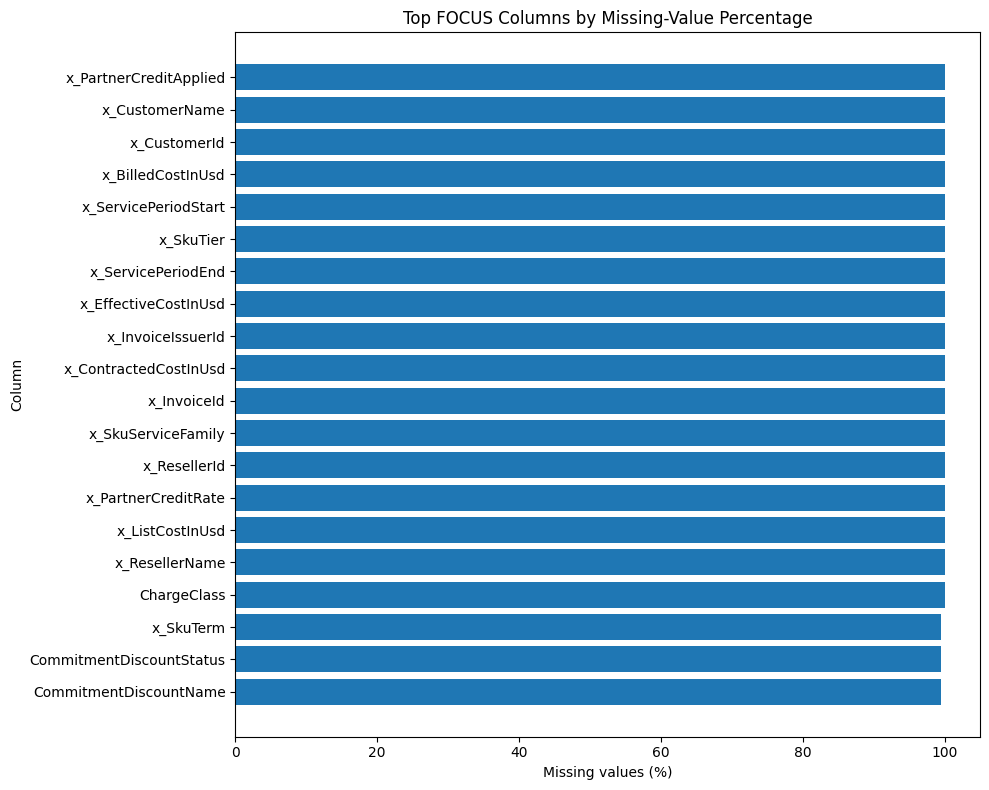

In [ ]:
missing_plot = (
    missing_summary[missing_summary["missing_count"] > 0]
    .head(20)
    .sort_values("missing_pct")
)

plt.figure(figsize=(10, 8))

plt.barh(
    missing_plot.index,
    missing_plot["missing_pct"]
)

plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.title("Top FOCUS Columns by Missing-Value Percentage")

plt.tight_layout()
plt.show()

In [ ]:
empty_columns = [
    column
    for column in focus_df.columns
    if focus_df[column].isna().all()
]

print("Completely empty columns:", len(empty_columns))

for column in empty_columns:
    print(" -", column)

Completely empty columns: 17
 - ChargeClass
 - x_BilledCostInUsd
 - x_ContractedCostInUsd
 - x_CustomerId
 - x_CustomerName
 - x_EffectiveCostInUsd
 - x_InvoiceId
 - x_InvoiceIssuerId
 - x_ListCostInUsd
 - x_PartnerCreditApplied
 - x_PartnerCreditRate
 - x_ResellerId
 - x_ResellerName
 - x_ServicePeriodEnd
 - x_ServicePeriodStart
 - x_SkuServiceFamily
 - x_SkuTier


In [ ]:
duplicate_count = focus_df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)
print(
    "Duplicate percentage:",
    round(duplicate_count / len(focus_df) * 100, 4),
    "%"
)

Exact duplicate rows: 0
Duplicate percentage: 0.0 %


In [ ]:
timestamp_columns = [
    "ChargePeriodStart",
    "ChargePeriodEnd"
]

for column in timestamp_columns:
    invalid_count = focus_df[column].isna().sum()

    print(
        f"{column}: "
        f"{invalid_count} invalid/missing timestamps"
    )

ChargePeriodStart: 0 invalid/missing timestamps
ChargePeriodEnd: 0 invalid/missing timestamps


created a new column here , so no. of columns became 96 to 97

In [ ]:
focus_df["ChargePeriodDuration"] = (
    focus_df["ChargePeriodEnd"]
    - focus_df["ChargePeriodStart"]
)

duration_summary = (
    focus_df["ChargePeriodDuration"]
    .describe()
)

duration_summary

,ChargePeriodDuration
count,135272
mean,1 days 00:00:00
std,0 days 00:00:00
min,1 days 00:00:00
25%,1 days 00:00:00
50%,1 days 00:00:00
75%,1 days 00:00:00
max,1 days 00:00:00


In [ ]:
focus_df["ChargePeriodDuration"].value_counts().head(20)

,count
ChargePeriodDuration,
1 days,135272


In [ ]:
invalid_periods = focus_df[
    focus_df["ChargePeriodEnd"]
    < focus_df["ChargePeriodStart"]
]

print("Invalid charge periods:", len(invalid_periods))

Invalid charge periods: 0


In [ ]:
print("BilledCost dtype:", focus_df["BilledCost"].dtype)

print(
    focus_df["BilledCost"]
    .head(10)
)

BilledCost dtype: float64
0    5.760000e-05
1    1.106411e-08
2    0.000000e+00
3    5.605405e-01
4   -1.500000e-06
5   -1.200000e-01
6    5.000000e-06
7    4.000000e-06
8    5.000000e-03
9    2.000000e-06
Name: BilledCost, dtype: float64


In [ ]:
focus_df["BilledCost"] = pd.to_numeric(
    focus_df["BilledCost"],
    errors="coerce"
)

print("BilledCost dtype:", focus_df["BilledCost"].dtype)

print(
    "Invalid BilledCost values:",
    focus_df["BilledCost"].isna().sum()
)

BilledCost dtype: float64
Invalid BilledCost values: 0


In [ ]:
cardinality_columns = [
    "ServiceName",
    "ResourceId",
    "ResourceType",
    "ChargeCategory"
]

cardinality = []

for column in cardinality_columns:
    cardinality.append({
        "column": column,
        "unique_values": focus_df[column].nunique(dropna=True),
        "missing_values": focus_df[column].isna().sum()
    })

cardinality_df = pd.DataFrame(cardinality)

cardinality_df

,column,unique_values,missing_values
0,ServiceName,36,0
1,ResourceId,642,0
2,ResourceType,52,0
3,ChargeCategory,2,0


In [ ]:
charge_category_counts = (
    focus_df["ChargeCategory"]
    .value_counts(dropna=False)
)

charge_category_counts

,count
ChargeCategory,
Usage,135271
Purchase,1


In [ ]:
non_usage = focus_df[
    focus_df["ChargeCategory"] != "Usage"
]

print("Non-Usage records:", len(non_usage))

display(non_usage)

Non-Usage records: 1


,BilledCost,BillingAccountId,BillingAccountName,BillingAccountType,BillingCurrency,BillingPeriodEnd,BillingPeriodStart,ChargeCategory,ChargeClass,ChargeDescription,ChargeFrequency,ChargePeriodEnd,ChargePeriodStart,CommitmentDiscountCategory,CommitmentDiscountId,CommitmentDiscountName,CommitmentDiscountStatus,CommitmentDiscountType,ConsumedQuantity,ConsumedUnit,ContractedCost,ContractedUnitPrice,EffectiveCost,InvoiceIssuerName,ListCost,ListUnitPrice,PricingCategory,PricingQuantity,PricingUnit,ProviderName,PublisherName,RegionId,RegionName,ResourceId,ResourceName,ResourceType,ServiceCategory,ServiceName,SkuId,SkuPriceId,SubAccountId,SubAccountName,SubAccountType,Tags,x_AccountId,x_AccountName,x_AccountOwnerId,x_BilledCostInUsd,x_BilledUnitPrice,x_BillingAccountId,x_BillingAccountName,x_BillingExchangeRate,x_BillingExchangeRateDate,x_BillingProfileId,x_BillingProfileName,x_ContractedCostInUsd,x_CostAllocationRuleName,x_CostCenter,x_CustomerId,x_CustomerName,x_EffectiveCostInUsd,x_EffectiveUnitPrice,x_InvoiceId,x_InvoiceIssuerId,x_InvoiceSectionId,x_InvoiceSectionName,x_ListCostInUsd,x_PartnerCreditApplied,x_PartnerCreditRate,x_PricingBlockSize,x_PricingCurrency,x_PricingSubcategory,x_PricingUnitDescription,x_PublisherCategory,x_PublisherId,x_ResellerId,x_ResellerName,x_ResourceGroupName,x_ResourceType,x_ServicePeriodEnd,x_ServicePeriodStart,x_SkuDescription,x_SkuDetails,x_SkuIsCreditEligible,x_SkuMeterCategory,x_SkuMeterId,x_SkuMeterName,x_SkuMeterSubcategory,x_SkuOfferId,x_SkuOrderId,x_SkuOrderName,x_SkuPartNumber,x_SkuRegion,x_SkuServiceFamily,x_SkuTerm,x_SkuTier,ChargePeriodDuration
64807,20.64,/providers/Microsoft.Billing/billingAccounts/8...,Trey Research Demo (DO NOT USE),Billing Account,USD,2024-07-01T00:00Z,2024-06-01T00:00Z,Purchase,NaN,Virtual Machines BS Series - B1s - US South Ce...,Recurring,2024-06-11 00:00:00+00:00,2024-06-10 00:00:00+00:00,Usage,/providers/Microsoft.Capacity/reservationOrder...,VM_RI_03-10-2023_07-59,NaN,Reservation,NaN,NaN,0.0,0.0,0.0,Microsoft,0.0,0.0,Standard,6.0,Hours,Microsoft,NaN,southcentralus,South Central US,/providers/microsoft.capacity/reservationorder...,76a36095-1eca-48ac-a578-c4ce775edeaa,Reservation order,Management and Governance,Azure Reservations,1049877.0,1049877,/subscriptions/ed570627-0265-4620-bb42-bae06bc...,Trey Research IT,Subscription,NaN,196312,ACM Team,acm@testea.onmicrosoft.com,NaN,0.0,8611537,Trey Research Demo (DO NOT USE),1,2024-06-01T00:00Z,8611537,Trey Research Demo (DO NOT USE),NaN,NaN,ACM9000,NaN,NaN,NaN,0.0,NaN,NaN,144867,ACM,NaN,NaN,NaN,1,USD,Standard,1 Hour,Cloud Provider,Microsoft,NaN,NaN,NaN,Microsoft.Capacity/reservationOrders,NaN,NaN,Virtual Machines BS Series - B1s - US South Ce...,NaN,True,Virtual Machines,4f69dc30-a2f8-40e8-9f2a-89ad061db198,B1s,BS Series,NaN,76a36095-1eca-48ac-a578-c4ce775edeaa,"Reserved VM Instance, Standard_B1s, US South C...",AAD-56564,US South Central,NaN,36.0,NaN,1 days


In [ ]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Original columns",
        "Current columns",
        "Derived columns added",
        "Missing cells",
        "Exact duplicate rows",
        "Invalid ChargePeriodStart",
        "Invalid ChargePeriodEnd",
        "Invalid charge periods",
        "Invalid BilledCost"
    ],
    "Value": [
        len(focus_df),
        EXPECTED_COLUMNS,
        focus_df.shape[1],
        focus_df.shape[1] - EXPECTED_COLUMNS,
        int(focus_df.isna().sum().sum()),
        int(duplicate_count),
        int(focus_df["ChargePeriodStart"].isna().sum()),
        int(focus_df["ChargePeriodEnd"].isna().sum()),
        int(len(invalid_periods)),
        int(focus_df["BilledCost"].isna().sum())
    ]
})

quality_summary

,Metric,Value
0,Rows,135272
1,Original columns,96
2,Current columns,97
3,Derived columns added,1
4,Missing cells,3595653
5,Exact duplicate rows,0
6,Invalid ChargePeriodStart,0
7,Invalid ChargePeriodEnd,0
8,Invalid charge periods,0
9,Invalid BilledCost,0


In [ ]:
cost_summary = focus_df["BilledCost"].describe()

cost_summary

,BilledCost
count,135272.000000
mean,0.262034
std,12.979328
min,-34.296000
25%,-0.000002
50%,0.000004
75%,0.000026
max,1105.897183


In [ ]:
negative_costs = (focus_df["BilledCost"] < 0).sum()
zero_costs = (focus_df["BilledCost"] == 0).sum()
positive_costs = (focus_df["BilledCost"] > 0).sum()

cost_category_summary = pd.DataFrame({
    "Category": [
        "Negative",
        "Zero",
        "Positive"
    ],
    "Count": [
        negative_costs,
        zero_costs,
        positive_costs
    ]
})

cost_category_summary["Percentage"] = (
    cost_category_summary["Count"]
    / len(focus_df)
    * 100
)

cost_category_summary

,Category,Count,Percentage
0,Negative,40143,29.675764
1,Zero,4289,3.170649
2,Positive,90840,67.153587


In [ ]:
total_billed_cost = focus_df["BilledCost"].sum()

print(f"Total Billed Cost: {total_billed_cost:,.6f}")

Total Billed Cost: 35,445.859030


In [ ]:
positive_cost_df = focus_df[
    focus_df["BilledCost"] > 0
].copy()

print("Positive-cost records:", len(positive_cost_df))
print(
    "Positive billed cost:",
    f"{positive_cost_df['BilledCost'].sum():,.6f}"
)

Positive-cost records: 90840
Positive billed cost: 41,196.803802


In [ ]:
negative_cost_df = focus_df[
    focus_df["BilledCost"] < 0
].copy()

print("Negative-cost records:", len(negative_cost_df))
print(
    "Total negative cost:",
    f"{negative_cost_df['BilledCost'].sum():,.6f}"
)

print(
    "Largest negative value:",
    f"{negative_cost_df['BilledCost'].min():,.6f}"
)

Negative-cost records: 40143
Total negative cost: -5,750.944772
Largest negative value: -34.296000


In [ ]:
largest_positive = (
    focus_df[
        focus_df["BilledCost"] > 0
    ]
    .nlargest(20, "BilledCost")
)

display(
    largest_positive[
        [
            "ChargePeriodStart",
            "BilledCost",
            "ServiceName",
            "ResourceType",
            "ChargeCategory"
        ]
    ]
)

,ChargePeriodStart,BilledCost,ServiceName,ResourceType,ChargeCategory
82498,2024-06-10 00:00:00+00:00,1105.897183,Microsoft.Fabric,Fabric Capacity,Usage
62940,2024-06-11 00:00:00+00:00,1105.866344,Microsoft.Fabric,Fabric Capacity,Usage
1215,2024-06-12 00:00:00+00:00,1105.843500,Microsoft.Fabric,Fabric Capacity,Usage
42999,2024-06-14 00:00:00+00:00,1105.843500,Microsoft.Fabric,Fabric Capacity,Usage
48837,2024-06-01 00:00:00+00:00,1105.843500,Microsoft.Fabric,Fabric Capacity,Usage
66309,2024-06-07 00:00:00+00:00,1105.843500,Microsoft.Fabric,Fabric Capacity,Usage
73049,2024-06-03 00:00:00+00:00,1105.843500,Microsoft.Fabric,Fabric Capacity,Usage
93082,2024-06-13 00:00:00+00:00,1105.843500,Microsoft.Fabric,Fabric Capacity,Usage
113276,2024-06-02 00:00:00+00:00,1105.843500,Microsoft.Fabric,Fabric Capacity,Usage
30720,2024-06-06 00:00:00+00:00,1105.841596,Microsoft.Fabric,Fabric Capacity,Usage


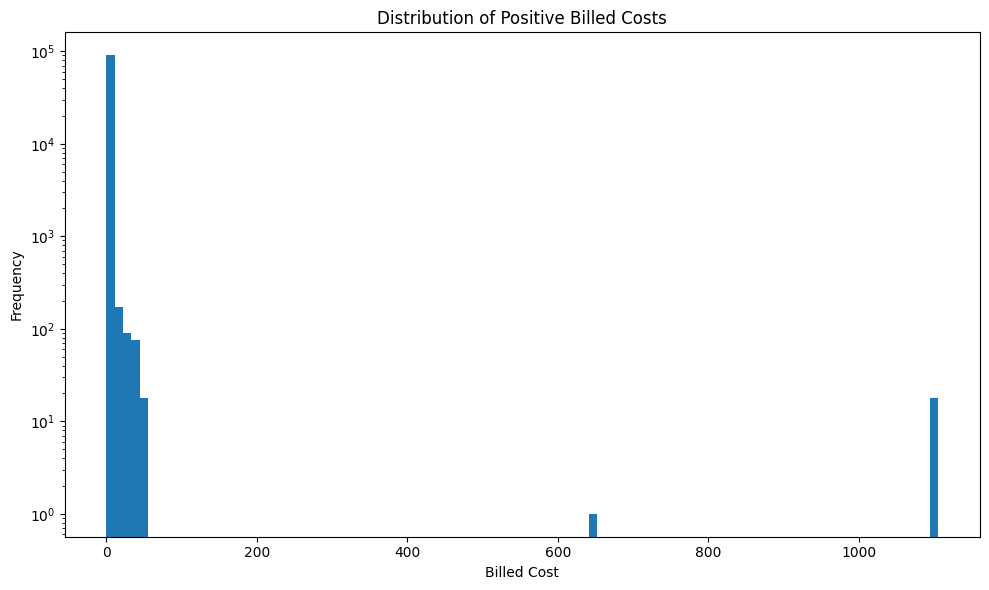

In [ ]:
positive_values = focus_df.loc[
    focus_df["BilledCost"] > 0,
    "BilledCost"
]

plt.figure(figsize=(10, 6))

plt.hist(
    positive_values,
    bins=100
)

plt.xlabel("Billed Cost")
plt.ylabel("Frequency")
plt.title("Distribution of Positive Billed Costs")

plt.yscale("log")

plt.tight_layout()
plt.show()

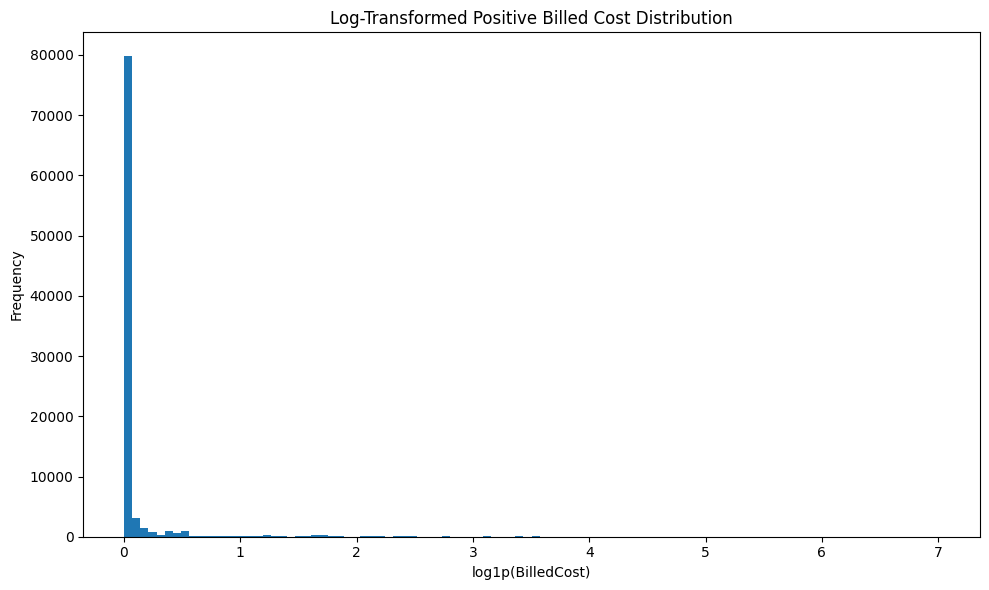

In [ ]:
log_cost = np.log1p(positive_values)

plt.figure(figsize=(10, 6))

plt.hist(
    log_cost,
    bins=100
)

plt.xlabel("log1p(BilledCost)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Positive Billed Cost Distribution")

plt.tight_layout()
plt.show()

# Service & Resource Analysis

In [ ]:
service_counts = (
    focus_df["ServiceName"]
    .value_counts(dropna=False)
)

print("Unique services:", focus_df["ServiceName"].nunique())

display(service_counts.head(20))

Unique services: 36


,count
ServiceName,
Storage Accounts,86157
Azure Machine Learning,22788
Virtual Machines,8795
Virtual Machine Scale Sets,3993
Virtual Network,2679
Azure App Service,1474
Key Vault,1386
Load Balancer,1273
Azure SQL Database,1207


In [ ]:
service_cost = (
    focus_df
    .groupby("ServiceName", dropna=False)["BilledCost"]
    .agg(
        total_cost="sum",
        mean_cost="mean",
        median_cost="median",
        record_count="size"
    )
    .sort_values("total_cost", ascending=False)
)

service_cost["cost_percentage"] = (
    service_cost["total_cost"]
    / focus_df["BilledCost"].sum()
    * 100
)

display(service_cost.head(20))

,total_cost,mean_cost,median_cost,record_count,cost_percentage
ServiceName,,,,,
Microsoft.Fabric,20730.480879,181.846324,3.064812e+00,114,58.484916
Virtual Machines,3288.603121,0.373917,6.321550e-03,8795,9.277820
Azure SQL Database,3170.270660,2.626571,3.354839e-01,1207,8.943980
Azure App Service,1972.106073,1.337928,0.000000e+00,1474,5.563714
SQL Database,1406.050617,5.492385,4.256000e+00,256,3.966756
Azure Data Factory,1032.703757,1.129873,1.000000e-05,914,2.913468
Virtual Network,778.471800,0.290583,1.200000e-01,2679,2.196228
Azure Synapse Analytics,656.106053,1.722063,6.208888e-03,381,1.851009
Virtual Machine Scale Sets,651.106917,0.163062,6.356835e-07,3993,1.836905


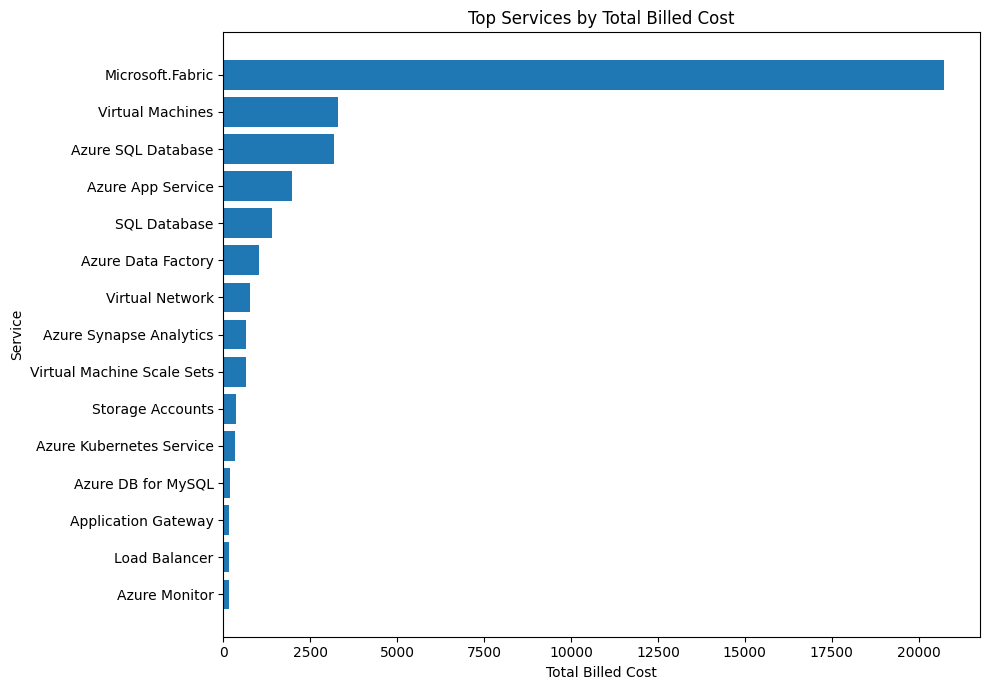

In [ ]:
top_services = (
    service_cost
    .head(15)
    .sort_values("total_cost")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_services.index.astype(str),
    top_services["total_cost"]
)

plt.xlabel("Total Billed Cost")
plt.ylabel("Service")
plt.title("Top Services by Total Billed Cost")

plt.tight_layout()
plt.show()

In [ ]:
service_cost_sorted = service_cost.sort_values(
    "total_cost",
    ascending=False
).copy()

service_cost_sorted["cumulative_cost_percentage"] = (
    service_cost_sorted["cost_percentage"].cumsum()
)

display(
    service_cost_sorted[
        [
            "total_cost",
            "cost_percentage",
            "cumulative_cost_percentage"
        ]
    ].head(20)
)

,total_cost,cost_percentage,cumulative_cost_percentage
ServiceName,,,
Microsoft.Fabric,20730.480879,58.484916,58.484916
Virtual Machines,3288.603121,9.277820,67.762736
Azure SQL Database,3170.270660,8.943980,76.706717
Azure App Service,1972.106073,5.563714,82.270430
SQL Database,1406.050617,3.966756,86.237186
Azure Data Factory,1032.703757,2.913468,89.150654
Virtual Network,778.471800,2.196228,91.346882
Azure Synapse Analytics,656.106053,1.851009,93.197891
Virtual Machine Scale Sets,651.106917,1.836905,95.034796


In [ ]:
resource_type_counts = (
    focus_df["ResourceType"]
    .value_counts(dropna=False)
)

print(
    "Unique resource types:",
    focus_df["ResourceType"].nunique()
)

display(resource_type_counts.head(20))

Unique resource types: 52


,count
ResourceType,
Storage account,85758
Azure Machine Learning workspace,22788
Disk,5921
Virtual machine scale set,3993
Virtual machine,2822
Public IP address,2413
Key vault,1386
Load balancer,931
Data factory (V2),914


In [ ]:
resource_type_cost = (
    focus_df
    .groupby("ResourceType", dropna=False)["BilledCost"]
    .agg(
        total_cost="sum",
        mean_cost="mean",
        median_cost="median",
        record_count="size"
    )
    .sort_values("total_cost", ascending=False)
)

resource_type_cost["cost_percentage"] = (
    resource_type_cost["total_cost"]
    / focus_df["BilledCost"].sum()
    * 100
)

display(resource_type_cost.head(20))

,total_cost,mean_cost,median_cost,record_count,cost_percentage
ResourceType,,,,,
Fabric Capacity,20730.480879,181.846324,3.064812e+00,114,58.484916
SQL database,2673.786499,3.445601,1.610000e-01,776,7.543297
Virtual machine,1728.643380,0.612560,3.245296e-05,2822,4.876856
Disk,1514.329884,0.255756,1.000080e-02,5921,4.272234
App Service Environment,1466.752000,11.028211,7.200000e+00,133,4.138007
SQL elastic pool,1406.050617,4.463653,1.543226e-01,315,3.966756
Data factory (V2),1032.703757,1.129873,1.000000e-05,914,2.913468
Virtual machine scale set,651.106917,0.163062,6.356835e-07,3993,1.836905
Virtual network gateway,645.120000,8.488421,4.560000e+00,76,1.820015


In [ ]:
resource_summary = (
    focus_df
    .groupby("ResourceId", dropna=False)["BilledCost"]
    .agg(
        total_cost="sum",
        mean_cost="mean",
        record_count="size"
    )
    .sort_values("total_cost", ascending=False)
)

print(
    "Unique resources:",
    focus_df["ResourceId"].nunique()
)

display(resource_summary.head(20))

Unique resources: 642


,total_cost,mean_cost,record_count
ResourceId,,,
/subscriptions/c9965926-e1b7-4bb1-87f0-f0f62ccb9ebb/resourcegroups/haven/providers/microsoft.fabric/capacities/havencapacity,20551.680879,360.555805,57
/subscriptions/1caaa5a3-2b66-438e-8ab4-bce37d518c5d/resourcegroups/ahbtest/providers/microsoft.sql/servers/ahbtest2/databases/ahbtestfoo,1196.666909,12.087545,99
/subscriptions/1caaa5a3-2b66-438e-8ab4-bce37d518c5d/resourcegroups/ahbtest/providers/microsoft.sql/servers/ahbtest1/elasticpools/ahbep,1179.880159,10.924816,108
/subscriptions/1caaa5a3-2b66-438e-8ab4-bce37d518c5d/resourcegroups/ahbtest/providers/microsoft.datafactory/factories/ahbtest02,1032.700140,31.293944,33
/subscriptions/1caaa5a3-2b66-438e-8ab4-bce37d518c5d/resourcegroups/ahbtest/providers/microsoft.compute/virtualmachines/sqlahbonvm,808.294087,6.466353,125
/subscriptions/ed570627-0265-4620-bb42-bae06bcfa914/resourcegroups/watchdog/providers/microsoft.web/hostingenvironments/watchdogenv/monthlystampfee_for_watchdogenv,692.160000,36.429474,19
/subscriptions/64e355d7-997c-491d-b0c1-8414dccfcf42/resourcegroups/webscreener/providers/microsoft.web/hostingenvironments/screenerenv/monthlystampfee_for_screenerenv,640.192000,11.231439,57
/subscriptions/64e355d7-997c-491d-b0c1-8414dccfcf42/resourcegroups/finopshubshack/providers/microsoft.synapse/workspaces/finopshubs-synpase/kustopools/finopshack22,636.194624,0.955247,666
/subscriptions/73c0021f-a37d-433f-8baa-7450cb54eea6/resourcegroups/celticqueen/providers/microsoft.network/virtualnetworkgateways/arcticring,560.000000,29.473684,19


/tmp/ipykernel_13234/2014559370.py:18: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


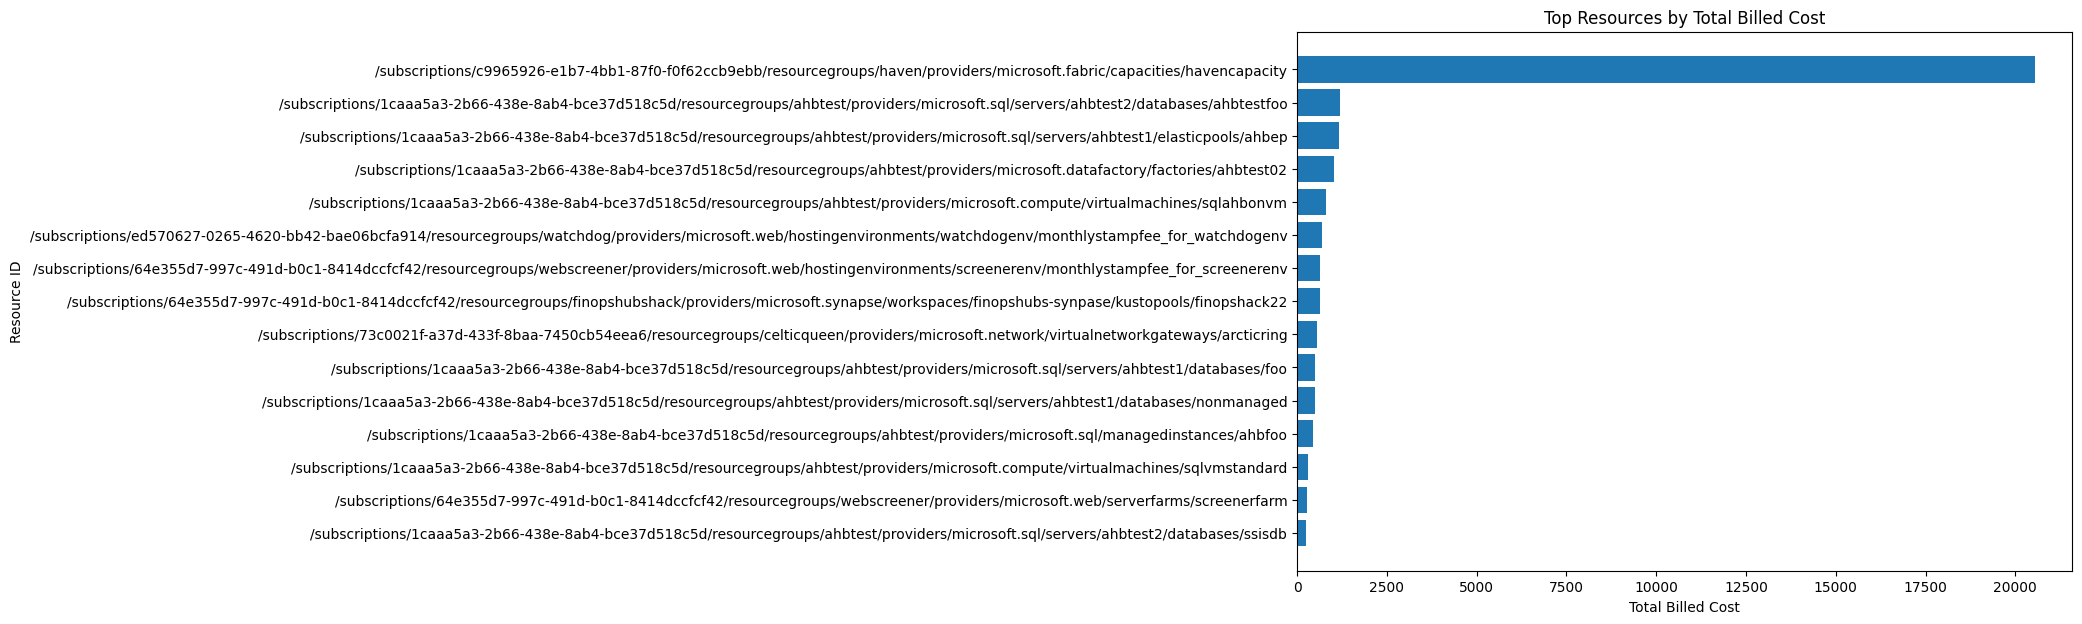

In [ ]:
top_resources = (
    resource_summary
    .head(15)
    .sort_values("total_cost")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_resources.index.astype(str),
    top_resources["total_cost"]
)

plt.xlabel("Total Billed Cost")
plt.ylabel("Resource ID")
plt.title("Top Resources by Total Billed Cost")

plt.tight_layout()
plt.show()

In [ ]:
focus_df["ChargeDate"] = (
    focus_df["ChargePeriodStart"]
    .dt.floor("D")
)

focus_df[
    ["ChargePeriodStart", "ChargeDate"]
].head()

,ChargePeriodStart,ChargeDate
0,2024-06-12 00:00:00+00:00,2024-06-12 00:00:00+00:00
1,2024-06-12 00:00:00+00:00,2024-06-12 00:00:00+00:00
2,2024-06-12 00:00:00+00:00,2024-06-12 00:00:00+00:00
3,2024-06-12 00:00:00+00:00,2024-06-12 00:00:00+00:00
4,2024-06-12 00:00:00+00:00,2024-06-12 00:00:00+00:00


In [ ]:
daily_cost = (
    focus_df
    .groupby("ChargeDate")
    .agg(
        total_billed_cost=("BilledCost", "sum"),
        positive_cost=("BilledCost", lambda x: x[x > 0].sum()),
        negative_cost=("BilledCost", lambda x: x[x < 0].sum()),
        record_count=("BilledCost", "size"),
        positive_records=("BilledCost", lambda x: (x > 0).sum()),
        negative_records=("BilledCost", lambda x: (x < 0).sum()),
        zero_records=("BilledCost", lambda x: (x == 0).sum())
    )
    .sort_index()
)

daily_cost

,total_billed_cost,positive_cost,negative_cost,record_count,positive_records,negative_records,zero_records
ChargeDate,,,,,,,
2024-06-01 00:00:00+00:00,1904.404825,2212.732394,-308.327569,6022,4026,1800,196
2024-06-02 00:00:00+00:00,1904.400802,2212.726314,-308.325512,6894,4607,2068,219
2024-06-03 00:00:00+00:00,1904.873045,2213.678081,-308.805036,6989,4671,2101,217
2024-06-04 00:00:00+00:00,1904.673862,2213.248007,-308.574144,7342,4904,2217,221
2024-06-05 00:00:00+00:00,1904.891794,2213.661672,-308.769879,7108,4781,2102,225
2024-06-06 00:00:00+00:00,1904.961667,2213.564456,-308.602788,7304,4904,2162,238
2024-06-07 00:00:00+00:00,1904.641874,2213.196524,-308.554650,7697,5178,2297,222
2024-06-08 00:00:00+00:00,1904.590855,2212.911134,-308.320279,6764,4549,1984,231
2024-06-09 00:00:00+00:00,1904.920156,2213.752977,-308.832820,7792,5239,2330,223


In [ ]:
print(
    "Sum of daily billed cost:",
    daily_cost["total_billed_cost"].sum()
)

print(
    "Original total billed cost:",
    focus_df["BilledCost"].sum()
)

assert np.isclose(
    daily_cost["total_billed_cost"].sum(),
    focus_df["BilledCost"].sum()
)

print("✓ Daily aggregation reconciles with the original dataset.")

Sum of daily billed cost: 35445.859030004576
Original total billed cost: 35445.85903000457
✓ Daily aggregation reconciles with the original dataset.


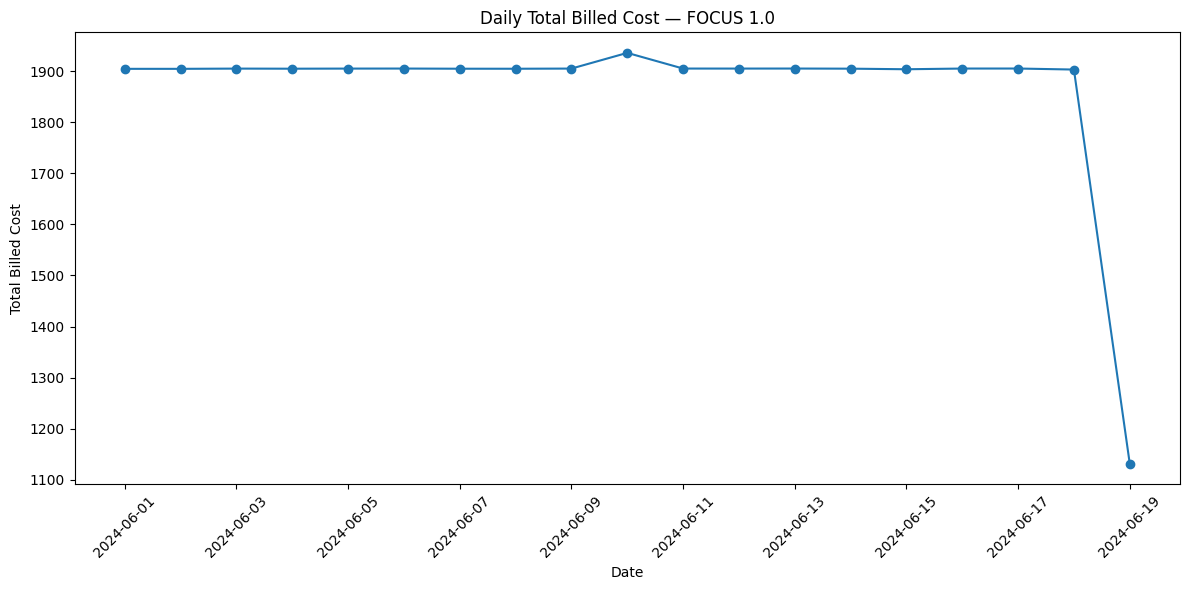

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_cost.index,
    daily_cost["total_billed_cost"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Total Billed Cost")
plt.title("Daily Total Billed Cost — FOCUS 1.0")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

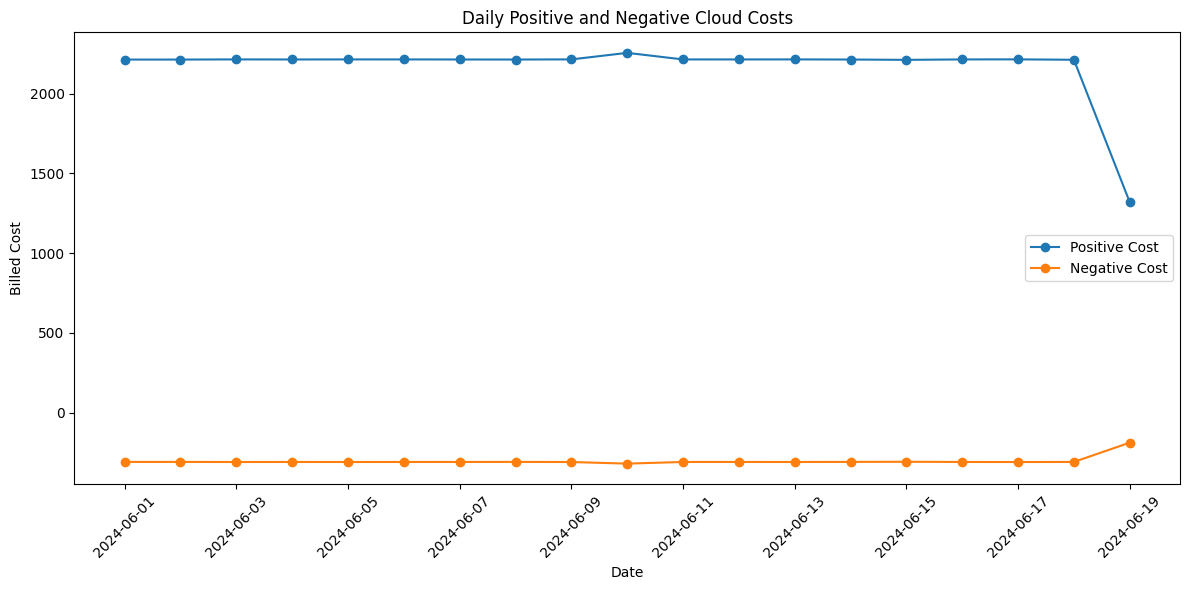

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    daily_cost.index,
    daily_cost["positive_cost"],
    marker="o",
    label="Positive Cost"
)

plt.plot(
    daily_cost.index,
    daily_cost["negative_cost"],
    marker="o",
    label="Negative Cost"
)

plt.xlabel("Date")
plt.ylabel("Billed Cost")
plt.title("Daily Positive and Negative Cloud Costs")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily_cost["total_billed_cost"].describe()

,total_billed_cost
count,19.000000
mean,1865.571528
std,177.863933
min,1131.675461
25%,1904.497840
50%,1904.873045
75%,1904.957240
max,1935.656994


# Cost concentration & final EDA

In [ ]:
service_cost_abs = (
    focus_df
    .groupby("ServiceName", dropna=False)["BilledCost"]
    .agg(
        total_cost="sum",
        absolute_cost=lambda x: x.abs().sum(),
        positive_cost=lambda x: x[x > 0].sum(),
        negative_cost=lambda x: x[x < 0].sum(),
        record_count="size"
    )
    .sort_values("positive_cost", ascending=False)
)

service_cost_abs["positive_cost_percentage"] = (
    service_cost_abs["positive_cost"]
    / focus_df.loc[
        focus_df["BilledCost"] > 0,
        "BilledCost"
    ].sum()
    * 100
)

display(service_cost_abs.head(20))

,total_cost,absolute_cost,positive_cost,negative_cost,record_count,positive_cost_percentage
ServiceName,,,,,,
Microsoft.Fabric,20730.480879,21088.080879,20909.280879,-178.800000,114,50.754619
Virtual Machines,3288.603121,4863.437115,4076.020118,-787.416997,8795,9.894020
Azure SQL Database,3170.270660,3730.230077,3450.250369,-279.979709,1207,8.375044
Azure App Service,1972.106073,4520.376220,3246.241147,-1274.135073,1474,7.879837
SQL Database,1406.050617,1858.391533,1632.221075,-226.170458,256,3.962009
Azure Synapse Analytics,656.106053,1968.318160,1312.212107,-656.106053,381,3.185228
Virtual Machine Scale Sets,651.106917,1953.320752,1302.213835,-651.106917,3993,3.160958
Azure Data Factory,1032.703757,1032.709670,1032.706713,-0.002957,914,2.506764
Virtual Network,778.471800,1118.133800,948.302800,-169.831000,2679,2.301884


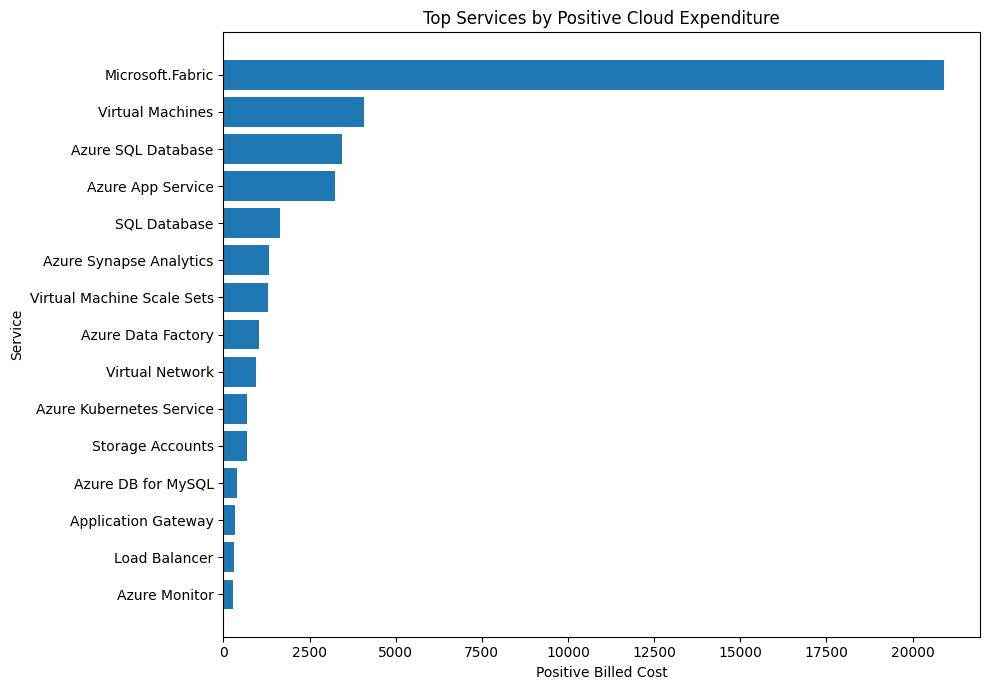

In [ ]:
top_service_positive = (
    service_cost_abs
    .head(15)
    .sort_values("positive_cost")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_service_positive.index.astype(str),
    top_service_positive["positive_cost"]
)

plt.xlabel("Positive Billed Cost")
plt.ylabel("Service")
plt.title("Top Services by Positive Cloud Expenditure")

plt.tight_layout()
plt.show()

In [ ]:
service_concentration = service_cost_abs.copy()

service_concentration["cumulative_positive_pct"] = (
    service_concentration["positive_cost_percentage"]
    .cumsum()
)

display(
    service_concentration[
        [
            "positive_cost",
            "positive_cost_percentage",
            "cumulative_positive_pct",
            "record_count"
        ]
    ].head(20)
)

,positive_cost,positive_cost_percentage,cumulative_positive_pct,record_count
ServiceName,,,,
Microsoft.Fabric,20909.280879,50.754619,50.754619,114
Virtual Machines,4076.020118,9.894020,60.648639,8795
Azure SQL Database,3450.250369,8.375044,69.023683,1207
Azure App Service,3246.241147,7.879837,76.903521,1474
SQL Database,1632.221075,3.962009,80.865530,256
Azure Synapse Analytics,1312.212107,3.185228,84.050758,381
Virtual Machine Scale Sets,1302.213835,3.160958,87.211716,3993
Azure Data Factory,1032.706713,2.506764,89.718480,914
Virtual Network,948.302800,2.301884,92.020365,2679


In [ ]:
resource_positive_cost = (
    focus_df
    .groupby("ResourceId", dropna=False)["BilledCost"]
    .agg(
        positive_cost=lambda x: x[x > 0].sum(),
        negative_cost=lambda x: x[x < 0].sum(),
        net_cost="sum",
        record_count="size"
    )
    .sort_values("positive_cost", ascending=False)
)

display(resource_positive_cost.head(20))

,positive_cost,negative_cost,net_cost,record_count
ResourceId,,,,
/subscriptions/c9965926-e1b7-4bb1-87f0-f0f62ccb9ebb/resourcegroups/haven/providers/microsoft.fabric/capacities/havencapacity,20551.680879,0.000000,20551.680879,57
/subscriptions/64e355d7-997c-491d-b0c1-8414dccfcf42/resourcegroups/webscreener/providers/microsoft.web/hostingenvironments/screenerenv/monthlystampfee_for_screenerenv,1280.384000,-640.192000,640.192000,57
/subscriptions/64e355d7-997c-491d-b0c1-8414dccfcf42/resourcegroups/finopshubshack/providers/microsoft.synapse/workspaces/finopshubs-synpase/kustopools/finopshack22,1272.389248,-636.194624,636.194624,666
/subscriptions/1caaa5a3-2b66-438e-8ab4-bce37d518c5d/resourcegroups/ahbtest/providers/microsoft.sql/servers/ahbtest2/databases/ahbtestfoo,1196.666909,0.000000,1196.666909,99
/subscriptions/1caaa5a3-2b66-438e-8ab4-bce37d518c5d/resourcegroups/ahbtest/providers/microsoft.sql/servers/ahbtest1/elasticpools/ahbep,1179.880159,0.000000,1179.880159,108
/subscriptions/1caaa5a3-2b66-438e-8ab4-bce37d518c5d/resourcegroups/ahbtest/providers/microsoft.datafactory/factories/ahbtest02,1032.700140,0.000000,1032.700140,33
/subscriptions/1caaa5a3-2b66-438e-8ab4-bce37d518c5d/resourcegroups/ahbtest/providers/microsoft.compute/virtualmachines/sqlahbonvm,808.294087,0.000000,808.294087,125
/subscriptions/ed570627-0265-4620-bb42-bae06bcfa914/resourcegroups/watchdog/providers/microsoft.web/hostingenvironments/watchdogenv/monthlystampfee_for_watchdogenv,692.160000,0.000000,692.160000,19
/subscriptions/73c0021f-a37d-433f-8baa-7450cb54eea6/resourcegroups/celticqueen/providers/microsoft.network/virtualnetworkgateways/arcticring,560.000000,0.000000,560.000000,19


In [ ]:
resource_type_positive = (
    focus_df
    .groupby("ResourceType", dropna=False)["BilledCost"]
    .agg(
        positive_cost=lambda x: x[x > 0].sum(),
        negative_cost=lambda x: x[x < 0].sum(),
        net_cost="sum",
        record_count="size"
    )
    .sort_values("positive_cost", ascending=False)
)

resource_type_positive["positive_cost_percentage"] = (
    resource_type_positive["positive_cost"]
    / focus_df.loc[
        focus_df["BilledCost"] > 0,
        "BilledCost"
    ].sum()
    * 100
)

display(resource_type_positive.head(20))

,positive_cost,negative_cost,net_cost,record_count,positive_cost_percentage
ResourceType,,,,,
Fabric Capacity,20909.280879,-178.800000,20730.480879,114,50.754619
SQL database,2908.806530,-235.020031,2673.786499,776,7.060758
App Service Environment,2241.344000,-774.592000,1466.752000,133,5.440577
Disk,2228.770003,-714.440118,1514.329884,5921,5.410056
Virtual machine,1801.620258,-72.976878,1728.643380,2822,4.373204
SQL elastic pool,1632.221075,-226.170458,1406.050617,315,3.962009
Virtual machine scale set,1302.213835,-651.106917,651.106917,3993,3.160958
Data Explorer pool,1272.389248,-636.194624,636.194624,666,3.088563
Data factory (V2),1032.706713,-0.002957,1032.703757,914,2.506764


In [ ]:
june_19 = focus_df[
    focus_df["ChargeDate"] == pd.Timestamp("2024-06-19", tz="UTC")
]

june_18 = focus_df[
    focus_df["ChargeDate"] == pd.Timestamp("2024-06-18", tz="UTC")
]

print("June 18")
print("Records:", len(june_18))
print("Positive cost:", june_18.loc[june_18["BilledCost"] > 0, "BilledCost"].sum())
print("Negative cost:", june_18.loc[june_18["BilledCost"] < 0, "BilledCost"].sum())
print()

print("June 19")
print("Records:", len(june_19))
print("Positive cost:", june_19.loc[june_19["BilledCost"] > 0, "BilledCost"].sum())
print("Negative cost:", june_19.loc[june_19["BilledCost"] < 0, "BilledCost"].sum())

June 18
Records: 6891
Positive cost: 2211.4586995704813
Negative cost: -308.45584182395703

June 19
Records: 6758
Positive cost: 1319.140149491575
Negative cost: -187.46468823558666


In [ ]:
june_18_service = (
    june_18
    .groupby("ServiceName")["BilledCost"]
    .sum()
    .rename("June18")
)

june_19_service = (
    june_19
    .groupby("ServiceName")["BilledCost"]
    .sum()
    .rename("June19")
)

service_change = pd.concat(
    [june_18_service, june_19_service],
    axis=1
).fillna(0)

service_change["change"] = (
    service_change["June19"]
    - service_change["June18"]
)

service_change = service_change.sort_values(
    "change"
)

display(service_change.head(15))

,June18,June19,change
ServiceName,,,
Microsoft.Fabric,1115.520046,651.120030,-464.400016
Azure SQL Database,171.011418,99.207235,-71.804183
Virtual Machines,175.320234,104.987940,-70.332294
Azure App Service,105.673258,69.987733,-35.685525
SQL Database,75.127706,45.647851,-29.479856
Azure Data Factory,55.200030,39.100200,-16.099830
Azure Synapse Analytics,35.223692,19.899385,-15.324307
Virtual Machine Scale Sets,35.067850,20.652642,-14.415208
Virtual Network,41.726400,27.396600,-14.329800


In [ ]:
display(service_change.tail(15))

,June18,June19,change
ServiceName,,,
API Management,1.579200,1.052800,-5.264000e-01
Azure Private Link,0.768387,0.480914,-2.874731e-01
Microsoft Defender for Cloud,0.644204,0.386460,-2.577440e-01
Azure Site Recovery,0.458689,0.294658,-1.640312e-01
Azure Container Registry,0.332669,0.207918,-1.247510e-01
Azure Data Factory v2,0.100583,0.059083,-4.150000e-02
Logic Apps,0.022099,0.000000,-2.209934e-02
Key Vault,0.016468,0.010354,-6.114000e-03
Azure DNS,0.016196,0.010797,-5.399144e-03


In [ ]:
final_summary = {
    "rows": len(focus_df),
    "original_columns": EXPECTED_COLUMNS,
    "derived_columns": focus_df.shape[1] - EXPECTED_COLUMNS,
    "date_start": focus_df["ChargePeriodStart"].min(),
    "date_end": focus_df["ChargePeriodStart"].max(),
    "unique_services": focus_df["ServiceName"].nunique(),
    "unique_resources": focus_df["ResourceId"].nunique(),
    "unique_resource_types": focus_df["ResourceType"].nunique(),
    "total_billed_cost": focus_df["BilledCost"].sum(),
    "positive_cost": focus_df.loc[
        focus_df["BilledCost"] > 0, "BilledCost"
    ].sum(),
    "negative_cost": focus_df.loc[
        focus_df["BilledCost"] < 0, "BilledCost"
    ].sum(),
    "zero_cost_records": int(
        (focus_df["BilledCost"] == 0).sum()
    ),
    "duplicate_rows": int(
        focus_df.duplicated().sum()
    )
}

final_summary_df = pd.DataFrame(
    final_summary.items(),
    columns=["Metric", "Value"]
)

final_summary_df

,Metric,Value
0,rows,135272
1,original_columns,96
2,derived_columns,2
3,date_start,2024-06-01 00:00:00+00:00
4,date_end,2024-06-19 00:00:00+00:00
5,unique_services,36
6,unique_resources,642
7,unique_resource_types,52
8,total_billed_cost,35445.85903
9,positive_cost,41196.803802


In [ ]:
FOCUS_PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

daily_output_path = (
    FOCUS_PROCESSED_DIR
    / "focus_daily_cost.csv"
)

daily_cost.reset_index().to_csv(
    daily_output_path,
    index=False
)

print("Saved:", daily_output_path)
print("Shape:", daily_cost.reset_index().shape)

Saved: /content/data/processed/focus_daily_cost.csv
Shape: (19, 8)


In [ ]:
enriched_output_path = (
    FOCUS_PROCESSED_DIR
    / "focus_eda_enriched.csv"
)

focus_df.to_csv(
    enriched_output_path,
    index=False
)

print("Saved:", enriched_output_path)
print("Shape:", focus_df.shape)

Saved: /content/data/processed/focus_eda_enriched.csv
Shape: (135272, 98)
